# Análise Exploratória e Limpeza de Dados (EDA)
Vamos limpar os metadados brutos do dataset MIQR-CC, alinhar as categorias com as 4 exigidas pelo enunciado e realizar a separação de treino, validação e teste.

## 0. Imports

In [1]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split,StratifiedGroupKFold
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn


## 1. Carregamento e Filtragem Base
Filtragem inicial: são mantidas apenas as imagens com Keep == 'Keep' e com label definida (excluindo Unlabelled)

In [2]:
# Caminho relativo limpo e padrão, partindo da pasta 'notebooks/'
csv_path = os.path.join("..", "data", "MIQR-CC-Dataset", "metadata.csv")

# Carregar o dataset
df = pd.read_csv(csv_path)

# Filtrar: Manter as marcadas como 'Keep' e descartar 'Unlabelled'
df_limpo = df[(df['Keep'] == 'Keep') & (df['Label'] != 'Unlabelled')].copy()

print(f"Total de imagens originais: {len(df)}")
print(f"Total de imagens úteis para treino: {len(df_limpo)}")

Total de imagens originais: 19317
Total de imagens úteis para treino: 1568


### 1.1. Visualização de Amostras
Vamos visualizar algumas imagens aleatórias que foram mantidas após a filtragem.

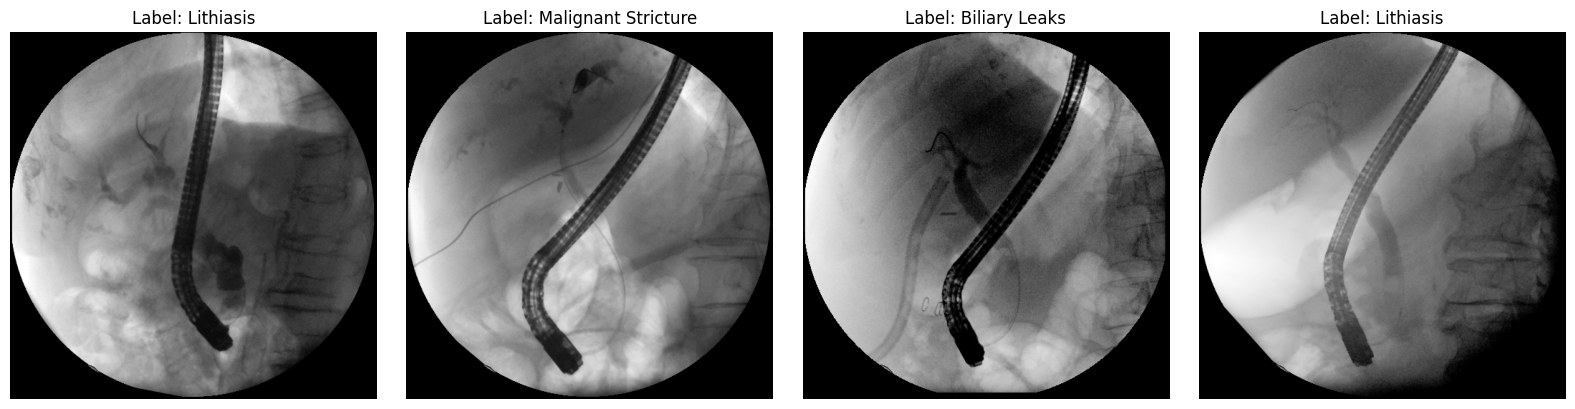

In [10]:
import matplotlib.pyplot as plt
import cv2

base_dir = os.path.join("..", "data", "MIQR-CC-Dataset")
amostras = df_limpo.sample(4)

plt.figure(figsize=(16, 4))
for i, (_, row) in enumerate(amostras.iterrows()):
    img_path = os.path.join(base_dir, row['processed_image_path'])
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    
    plt.subplot(1, 4, i + 1)
    if img is not None:
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {row['Label']}")
        plt.axis('off')
    else:
        plt.text(0.5, 0.5, 'Erro ao carregar', ha='center', va='center')
        plt.title(f"Label: {row['Label']}")
        plt.axis('off')

plt.tight_layout()
plt.show()

## 2. Mapeamento de Classes
O dataset divide as estenoses em malignas e benignas. Vamos mapear os dados para as 4 classes obrigatórias: **Biliary_Leaks, Lithiasis, Stricture e Normal**.

In [3]:
def mapear_classes(label):
    if label == 'Biliary Leaks':
        return 'Biliary_Leaks' # Adicionar o underscore
    elif label in ['Malignant Stricture', 'Benign Stricture']:
        return 'Stricture' # Agrupar as estenoses
    else:
        return label

# Criar uma nova coluna com os nomes padronizados
df_limpo['Label_Mapped'] = df_limpo['Label'].apply(mapear_classes)

## 3. Distribuição das Classes (Balanceamento)
Verificação do rácio de patologias para posterior cálculo dos Class Weights.

In [4]:
print("--- Distribuição das Classes ---")
contagem = df_limpo['Label_Mapped'].value_counts()
percentagem = df_limpo['Label_Mapped'].value_counts(normalize=True) * 100

for classe, qtd in contagem.items():
    print(f"Classe: {classe:<15} | Quantidade: {qtd:<5} | Proporção: {percentagem[classe]:.2f}%")

--- Distribuição das Classes ---
Classe: Lithiasis       | Quantidade: 726   | Proporção: 46.30%
Classe: Stricture       | Quantidade: 392   | Proporção: 25.00%
Classe: Normal          | Quantidade: 299   | Proporção: 19.07%
Classe: Biliary_Leaks   | Quantidade: 151   | Proporção: 9.63%


### 3.1. Análise por Doente (Patient-Level) 

Para além da distribuição por imagem, analisamos a distribuição ao nível do doente para detetar possível enviesamento no dataset.

In [5]:
def contagem_pacientes(df, label_col='Label_Mapped', patient_col='patient_id'):
    """
    Calcula e exibe o total de pacientes únicos e a distribuição por classe.
    """
    total_pacientes = df[patient_col].nunique()
    total_imagens = len(df)
    
    print("=" * 50)
    print(" ANÁLISE DE DOENTES / PACIENTES")
    print("=" * 50)
    print(f"Total de Imagens no Dataset   : {total_imagens}")
    print(f"Total de Pacientes Únicos     : {total_pacientes}")
    print(f"Média de Imagens por Paciente : {total_imagens / total_pacientes:.2f}")
    print("-" * 50)
    
    print("Doentes Únicos por Classe:")
    for classe in sorted(df[label_col].unique()):
        df_classe = df[df[label_col] == classe]
        pats_classe = df_classe[patient_col].nunique()
        imgs_classe = len(df_classe)
        print(f" 🔹 {classe:<20} | Pacientes: {pats_classe:>3} | Imagens: {imgs_classe:>3}")
    print("=" * 50)

# --- Exemplo de Uso: ---
contagem_pacientes(df_limpo)


 ANÁLISE DE DOENTES / PACIENTES
Total de Imagens no Dataset   : 1568
Total de Pacientes Únicos     : 436
Média de Imagens por Paciente : 3.60
--------------------------------------------------
Doentes Únicos por Classe:
 🔹 Biliary_Leaks        | Pacientes:  26 | Imagens: 151
 🔹 Lithiasis            | Pacientes: 209 | Imagens: 726
 🔹 Normal               | Pacientes: 146 | Imagens: 299
 🔹 Stricture            | Pacientes: 105 | Imagens: 392


### Divisão dos dados em 70% Treino, 15% Validação e 15% Teste usando StratifiedGroupKFold

Garante: (1) proporcionalidade das classes em cada split, e (2) que todas as imagens do mesmo doente (patient_id) ficam no mesmo split (sem patient leakage). A divisão é feita em 2 etapas: primeiro 10 folds para separar 70%/30%, depois 2 folds para dividir o 30% em Val/Test.

In [6]:
SEMENTE = 42 

# 1º Split: Treino (70%) e Resto (30%)
#train_df, rest_df = train_test_split(
    #df_limpo, test_size=0.30, random_state=SEMENTE, stratify=df_limpo['Label_Mapped'])

# 2º Split: Validação (15%) e Teste (15%)
#val_df, test_df = train_test_split(
    #rest_df, test_size=0.50, random_state=SEMENTE, stratify=rest_df['Label_Mapped'])

groups = df_limpo['patient_id']
y = df_limpo['Label_Mapped']

# -------------------------------------------------------------
# ETAPA 1: Dividir em 10 Folds (7 Folds = 70% Treino, 3 Folds = 30% Resto)
# -------------------------------------------------------------

sgkf1 = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=SEMENTE)

# Mapeamos em qual fold cada amostra cai
fold_ids = np.zeros(len(df_limpo), dtype=int)
for fold_idx, (train_idx, val_idx) in enumerate(sgkf1.split(df_limpo, y, groups=groups)):
    fold_ids[val_idx] = fold_idx

# Folds 0, 1, 2 vão para o Resto (30%) e as restantes 3-9 para o Treino (70%)
rest_idx = np.where(fold_ids < 3)[0]
train_idx = np.where(fold_ids >= 3)[0]
train_df = df_limpo.iloc[train_idx]
rest_df  = df_limpo.iloc[rest_idx]


# -------------------------------------------------------------
# ETAPA 2: Dividir os 30% do Resto em 2 partes iguais (15% Val / 15% Test)
# -------------------------------------------------------------
rest_groups = rest_df['patient_id']
rest_y = rest_df['Label_Mapped']
sgkf2 = StratifiedGroupKFold(n_splits=2, shuffle=True, random_state=SEMENTE)

# Divide a meio (50% de 30% = 15% cada)

for val_idx_rest, test_idx_rest in sgkf2.split(rest_df, rest_y, groups=rest_groups):
    val_df  = rest_df.iloc[val_idx_rest]
    test_df = rest_df.iloc[test_idx_rest]
    break # Só precisamos da primeira partição para dividir ao meio



print(f"Subconjunto de Treino:    {len(train_df)} imagens")
print(f"Subconjunto de Validação: {len(val_df)} imagens")
print(f"Subconjunto de Teste:     {len(test_df)} imagens")

# Guardar em CSVs para serem lidos pelo data_setup.py no momento do treino
pasta_splits = os.path.join("..", "data", "MIQR-CC-Dataset", "splits")
os.makedirs(pasta_splits, exist_ok=True)

train_df.to_csv(os.path.join(pasta_splits, "train.csv"), index=False)
val_df.to_csv(os.path.join(pasta_splits, "val.csv"), index=False)
test_df.to_csv(os.path.join(pasta_splits, "test.csv"), index=False)
print(f"\nSucesso! Ficheiros guardados em: {pasta_splits}")

Subconjunto de Treino:    1106 imagens
Subconjunto de Validação: 231 imagens
Subconjunto de Teste:     231 imagens

Sucesso! Ficheiros guardados em: ..\data\MIQR-CC-Dataset\splits


### Verificação de Estratificação e Patient Leakage nos Splits 

Verifica se a divisão Train/Val/Test mantém a proporcionalidade das classes e garante que não há partilha de doentes entre splits (patient leakage = 0)."

In [7]:
import pandas as pd
import numpy as np

def analisar_splits(train_df, val_df, test_df, label_col='Label_Mapped', patient_col='patient_id', class_names=None):
    """
    Analisa os splits (treino, validação e teste) para verificar a estratificação 
    de classes e a separação de doentes (patient leakage).
    """
    splits = {
        'Treino': train_df,
        'Validação': val_df,
        'Teste': test_df
    }
    
    total_imagens = sum(len(df) for df in splits.values())
    
    print("=" * 60)
    print(" 📊 ANÁLISE GERAL DOS SPLITS")
    print("=" * 60)
    
    # 1. Proporções Gerais e Pacientes Únicos
    pacientes_por_split = {}
    for nome, df in splits.items():
        n_imgs = len(df)
        pct_imgs = (n_imgs / total_imagens) * 100
        n_pats = df[patient_col].nunique()
        pacientes_por_split[nome] = set(df[patient_col].unique())
        
        print(f"🔹 {nome:<10} | Imagens: {n_imgs:>4} ({pct_imgs:>5.1f}%) | Pacientes Únicos: {n_pats:>3}")
        
    print("\n" + "=" * 60)
    print(" 🔍 VERIFICAÇÃO DE PATIENT LEAKAGE (Deve ser 0!)")
    print("=" * 60)
    
    # Interseções de pacientes
    treino_val = pacientes_por_split['Treino'].intersection(pacientes_por_split['Validação'])
    treino_teste = pacientes_por_split['Treino'].intersection(pacientes_por_split['Teste'])
    val_teste = pacientes_por_split['Validação'].intersection(pacientes_por_split['Teste'])
    
    leakage = False
    if len(treino_val) > 0:
        print(f"❌ LEAKAGE DETETADO: {len(treino_val)} doente(s) partilhado(s) entre Treino e Validação!")
        leakage = True
    if len(treino_teste) > 0:
        print(f"❌ LEAKAGE DETETADO: {len(treino_teste)} doente(s) partilhado(s) entre Treino e Teste!")
        leakage = True
    if len(val_teste) > 0:
        print(f"❌ LEAKAGE DETETADO: {len(val_teste)} doente(s) partilhado(s) entre Validação e Teste!")
        leakage = True
        
    if not leakage:
        print("✅ Excelente! Interseção nula de pacientes entre os conjuntos (0% Leakage).")
        
    print("\n" + "=" * 60)
    print(" ⚖️ ESTRATIFICAÇÃO DAS CLASSES (Representação por Split)")
    print("=" * 60)
    
    # Processamento correto do mapeamento das chaves
    if class_names is None:
        todas_classes = sorted(train_df[label_col].unique())
        class_names_map = {c: c for c in todas_classes}
    elif isinstance(class_names, list):
        class_names_map = {name: name for name in class_names}
    else:
        class_names_map = class_names
        
    # Calcular a distribuição de classes
    distribuicoes = {}
    for nome, df in splits.items():
        contagem = df[label_col].value_counts().to_dict()
        total = len(df)
        distribuicoes[nome] = {cls: (contagem.get(cls, 0), (contagem.get(cls, 0) / total) * 100) 
                               for cls in class_names_map.keys()}
        
    # Imprimir cabeçalho das colunas
    print(f"{'Classe / Label':<20} | {'Treino':^15} | {'Validação':^15} | {'Teste':^15}")
    print("-" * 75)
    
    for cls_key, cls_display in class_names_map.items():
        t_count, t_pct = distribuicoes['Treino'].get(cls_key, (0, 0))
        v_count, v_pct = distribuicoes['Validação'].get(cls_key, (0, 0))
        te_count, te_pct = distribuicoes['Teste'].get(cls_key, (0, 0))
        
        print(f"{cls_display:<20} | {t_count:>3} ({t_pct:>4.1f}%) | {v_count:>3} ({v_pct:>4.1f}%) | {te_count:>3} ({te_pct:>4.1f}%)")
    print("=" * 75)


# --- Exemplo de Uso no Notebook: ---
CLASS_NAMES = ["Biliary_Leaks", "Lithiasis", "Stricture", "Normal"]
analisar_splits(train_df, val_df, test_df, class_names=CLASS_NAMES)


 📊 ANÁLISE GERAL DOS SPLITS
🔹 Treino     | Imagens: 1106 ( 70.5%) | Pacientes Únicos: 309
🔹 Validação  | Imagens:  231 ( 14.7%) | Pacientes Únicos:  66
🔹 Teste      | Imagens:  231 ( 14.7%) | Pacientes Únicos:  61

 🔍 VERIFICAÇÃO DE PATIENT LEAKAGE (Deve ser 0!)
✅ Excelente! Interseção nula de pacientes entre os conjuntos (0% Leakage).

 ⚖️ ESTRATIFICAÇÃO DAS CLASSES (Representação por Split)
Classe / Label       |     Treino      |    Validação    |      Teste     
---------------------------------------------------------------------------
Biliary_Leaks        | 115 (10.4%) |  17 ( 7.4%) |  19 ( 8.2%)
Lithiasis            | 507 (45.8%) | 110 (47.6%) | 109 (47.2%)
Stricture            | 275 (24.9%) |  59 (25.5%) |  58 (25.1%)
Normal               | 209 (18.9%) |  45 (19.5%) |  45 (19.5%)


## 5. Estratégias de Desequilíbrio: Class Weights
Como detetámos um forte desequilíbrio entre as classes (ex: quase 5x mais imagens de *Lithiasis* do que de *Biliary_Leaks*), precisamos de penalizar mais o modelo quando este erra nas classes minoritárias. 

Vamos utilizar a biblioteca `scikit-learn` para calcular os pesos balanceados rigorosos.

In [8]:

# 1. Obter as labels exatas que temos no dataset limpo
labels = train_df['Label_Mapped'].values
classes_unicas = np.unique(labels)

# 2. Calcular os pesos balanceados automaticamente
pesos = compute_class_weight(class_weight='balanced', classes=classes_unicas, y=labels)

# 3. Criar um dicionário para visualizar melhor
pesos_dict = dict(zip(classes_unicas, pesos))

print("--- Pesos Calculados por Classe ---")
for classe, peso in pesos_dict.items():
    print(f"{classe:<15}: {peso:.4f}")

--- Pesos Calculados por Classe ---
Biliary_Leaks  : 2.4043
Lithiasis      : 0.5454
Normal         : 1.3230
Stricture      : 1.0055


### 5.1. Preparação para a Função de Perda (CrossEntropyLoss)
No PyTorch, para passarmos estes pesos para a função de erro, precisamos que eles estejam num Tensor (vetor matemático) e **exatamente na mesma ordem** que definimos no nosso dicionário de mapeamento no ficheiro `data_setup.py` (0: Biliary_Leaks, 1: Lithiasis, 2: Stricture, 3: Normal).

In [9]:

# Ordem exigida pelo nosso data_setup.py
ordem_classes = ['Biliary_Leaks', 'Lithiasis', 'Stricture', 'Normal']

# Organizar os pesos nessa ordem
pesos_ordenados = [pesos_dict[c] for c in ordem_classes]

# Converter para um Tensor do PyTorch
tensor_pesos = torch.tensor(pesos_ordenados, dtype=torch.float)
print(f"\nTensor de Pesos final para o PyTorch: \n{tensor_pesos}")

# Como será injetado na Tarefa 4:
criterio = nn.CrossEntropyLoss(weight=tensor_pesos)
print("\nPreparação concluída! O critério já está configurado para lidar com o desequilíbrio.")


Tensor de Pesos final para o PyTorch: 
tensor([2.4043, 0.5454, 1.0055, 1.3230])

Preparação concluída! O critério já está configurado para lidar com o desequilíbrio.
